In [25]:
import numpy as np 

In [26]:
import pandas as pd

In [27]:
import matplotlib.pyplot as plt

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
from sklearn.linear_model import LinearRegression 

In [30]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [31]:
data = {
    'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0,
                        3.2, 3.2, 3.7, 3.9, 4.0, 4.0, 4.1,
                        4.5, 4.9, 5.1, 5.3, 5.9, 6.0, 6.8,
                        7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6,
                        10.3, 10.5],
    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150,
               54445, 64445, 57189, 63218, 55794, 56957, 57081,
               61111, 67938, 66029, 83088, 81363, 93940, 91738,
               98273, 101302, 113812, 109431, 105582, 116969,
               112635, 122391, 121872]
}

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
print(df.describe())

Dataset shape: (30, 2)
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


In [32]:
df.sample()

,YearsExperience,Salary
0,1.1,39343


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [34]:
X_vals = df["YearsExperience"].values
y_vals = df["Salary"].values

n = len(X_vals)

m_manual = (
    (n*np.sum(X_vals*y_vals))
    -
    (np.sum(X_vals)*np.sum(y_vals))
)/(
    (n*np.sum(X_vals**2))
    -
    (np.sum(X_vals)**2)
)

b_manual = (
    np.sum(y_vals)
    -
    m_manual*np.sum(X_vals)
)/n

In [35]:
print(m_manual)
print(b_manual)

9449.962321455077
25792.200198668685


In [36]:
X = df[['YearsExperience']]
y = df['Salary']

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.8, random_state = 42)

In [38]:
lr = LinearRegression()

In [39]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:

print(lr.coef_)
print(lr.intercept_)

[10553.01636569]
22574.891930022575


In [41]:
X_train.shape

(6, 1)

In [42]:
X_train

,YearsExperience
20,6.8
7,3.2
10,3.9
14,4.5
19,6.0
6,3.0


In [43]:
y_pred = lr.predict(X_test)

In [44]:
print(y_pred)

[123883.84904063  74284.6721219  109109.62612867  78505.87866817
  56344.54430023  61621.05248307 131270.96049661 114386.13431151
  64786.95739278  34183.20993228  45791.52793454  76395.27539503
  53178.63939052  65842.25902935  64786.95739278 105943.72121896
  36293.81320542  38404.41647856 117552.03922122  43680.9246614
  97501.30812641 122828.54740406  84837.68848758 133381.56376975]


In [52]:
import pandas as pd

def predict_salary(years):

    years = float(years)

    input_df = pd.DataFrame({
        "YearsExperience": [years]
    })

    prediction = lr.predict(input_df)[0]

    print(f"{years} Years Experience → ₹{prediction:,.0f}")
predict_salary(2)
predict_salary(5)
predict_salary(8)
predict_salary(10)

2.0 Years Experience → ₹43,681
5.0 Years Experience → ₹75,340
8.0 Years Experience → ₹106,999
10.0 Years Experience → ₹128,105


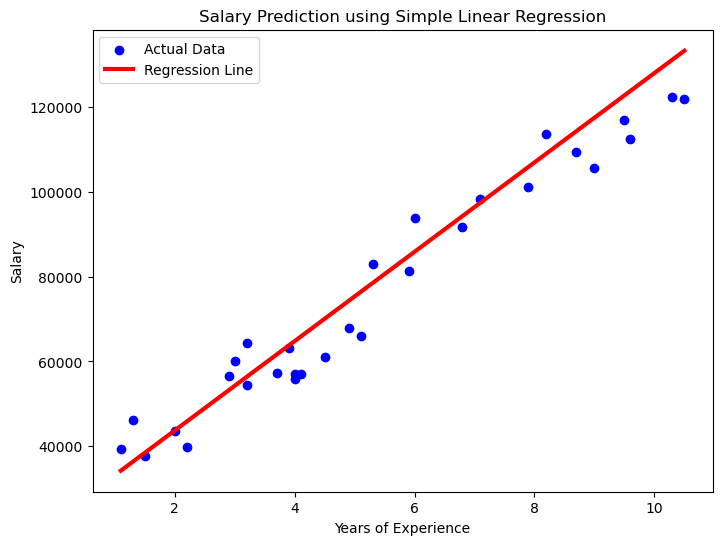

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(X, y, color="blue", label="Actual Data")

plt.plot(
    X.sort_values("YearsExperience"),
    lr.predict(X.sort_values("YearsExperience")),
    color="red",
    linewidth=3,
    label="Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction using Simple Linear Regression")
plt.legend()

plt.show()

In [54]:
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [55]:
print(mse)
print(rmse)
print(mae)
print(r2)

51726586.16681818
7192.119726952422
6362.063628668172
0.9381853544796769


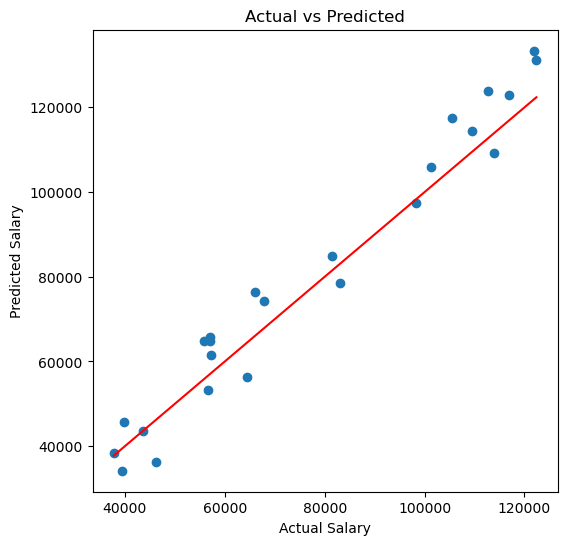

In [56]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")

plt.show()

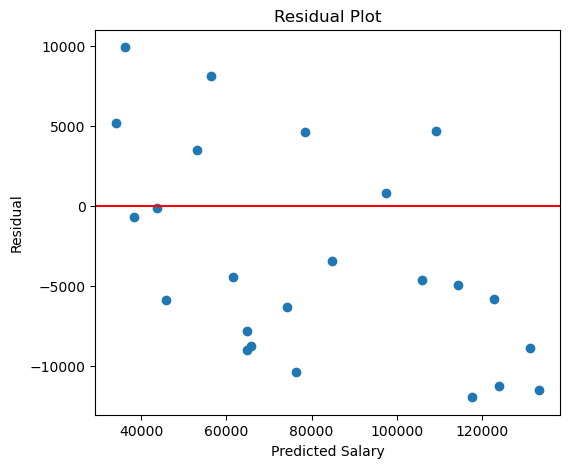

In [57]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Salary")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()